In [9]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv
import folium
import datetime
import seaborn as sns
import scipy as sp
import statsmodels.formula.api as smf
import networkx as nx
import missingno as msno
import os
import sys
import urllib.request
import time
import json
import plotly.express as px
import re
import sklearn.metrics as metrics

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_diabetes
from folium.plugins import HeatMap 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from dateutil.relativedelta import relativedelta
from sklearn.cluster import KMeans    
from yellowbrick.cluster import KElbowVisualizer
from scipy.cluster.hierarchy import dendrogram, linkage
from mpl_toolkits.mplot3d import Axes3D
from operator import itemgetter
from PIL import Image
from collections import Counter
from wordcloud import WordCloud
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import r2_score, ConfusionMatrixDisplay, confusion_matrix, accuracy_score, silhouette_score
from sklearn.neighbors import KNeighborsClassifier

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

# [영문분석+워드클라우드] - 영문 문서 제목의 키워드 분석하기

* 와인 데이터가 숫자를 보고 '품질'을 맞혔다면, 학술 데이터에서는 단어의 빈도를 보고 '연구 흐름'을 읽어낼 것입니다.
* 컴퓨터에게 영문 단어만 골라내게 하고, 'the', 'a' 같은 의미 없는 단어들을 청소(Preprocessing)한 뒤,
* 가장 많이 외쳐진 단어를 크게 보여주는 워드클라우드를 만드는 것이죠.

## 1. 데이터셋 출처 (데이터 가져오기)
* 본 데이터셋은 **RISS(학술연구정보서비스)**에서 'Big Data' 또는 'School' 등의 키워드로 검색된 학술지 논문의 정보를 엑셀 형식으로 수집한 것입니다.
* 수천 건의 연구 제목과 초록 데이터를 분석하여 해당 분야의 주요 연구 키워드와 흐름을 파악하는 것이 목표입니다.
* 출처: RISS (학술연구정보서비스)
* 파일명: myCabinetExcelData*.xls (또는 수집된 키워드명.xls)

## 2. 데이터 구성 (Feature Description)
논문의 서지 정보와 핵심 내용을 담은 주요 컬럼들로 구성되어 있습니다.
* 번호 (No): 논문의 일련번호
* 제목 (Title): 논문의 국문 또는 영문 제목 (텍스트 분석의 핵심 대상)
* 저자 (Author): 논문을 작성한 연구자 성명
* 발행기관 (Publisher): 논문이 게재된 학회 또는 대학교 이름
* 학술지명 (Journal): 논문이 실린 학술지 명칭
* 발행연도 (Publication Year): 논문이 발표된 연도 (연도별 트렌드 분석 시 활용)
* 주제어 (Keywords): 저자가 직접 선정한 논문의 핵심 단어
* 초록 (Abstract): 논문의 전체 내용을 요약한 짧은 글 (상세 텍스트 분석 시 활용)
* 자료유형 (Type): 학술지 논문, 학위 논문 등 자료의 형태

## 3. 필요 라이브러리
uv add pandas numpy matplotlib seaborn nltk wordcloud xlrd openpyxl

In [10]:
import warnings
warnings.filterwarnings(action='ignore') 

import os
import sys
import json
import csv
import datetime
import webbrowser
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from operator import itemgetter
from dateutil.relativedelta import relativedelta

# 그래프 한글 폰트 설정 (Windows: 맑은 고딕)
# plt.rc('font', family='Malgun Gothic')
# plt.rcParams['axes.unicode_minus'] = False 


import nltk
import glob
import re

from functools import reduce
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud, STOPWORDS
from collections import Counter

In [26]:
# 텍스트분석에 필요한 데이터셋 (모든 데이터셋을 다운로드)
# nltk.download('all')    # 3.5G 
nltk.download('popular')    # 유명한 자료만 다운로드 750M 정도

[nltk_data] Downloading collection 'popular'
[nltk_data]    | 
[nltk_data]    | Downloading package cmudict to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package gazetteers to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/gazetteers.zip.
[nltk_data]    | Downloading package genesis to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/genesis.zip.
[nltk_data]    | Downloading package gutenberg to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/gutenberg.zip.
[nltk_data]    | Downloading package inaugural to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/inaugural.zip.
[nltk_data]    | Downloading package movie_reviews to
[nltk_data]    |     /home/erion/nltk_data...
[nltk_data]    |   Unzipping corpora/movie_reviews.zip.
[nltk_data]    | Downloading package names to /

True

## 4. 데이터 수집

In [27]:
all_files = glob.glob("../../data/myCabinetExcelData/myCabinetExcelData*.xlsx")
all_files

['../../data/myCabinetExcelData/myCabinetExcelData.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData1.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData2.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData3.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData4.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData5.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData6.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData7.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData8.xlsx',
 '../../data/myCabinetExcelData/myCabinetExcelData9.xlsx']

In [28]:
all_files_data = [] 
for file in all_files:
    data_frame = pd.read_excel(file)  
    all_files_data.append(data_frame) 
    
all_files_data[0]

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Architecting Time-Critical Big-Data Systems,"Basanta-Val, P.; Audsley, N. C.; Wellings, A. ...",unknown,2016
1,NaN,2,A trust-based crowdfunding campaign marketing ...,"Baah-Peprah, Prince; Shneor, Rotem",Inderscience,2021
2,NaN,3,A Game Theoretic Approach for Addressing Domai...,"Raghavan, Krishnan",unknown,2022
3,NaN,4,Computation migration: a new approach to execu...,"Nunes, Rickey T. P.; Deshpande, Santosh L.",Inderscience,2018
4,NaN,5,Big-BOE: Fusing Spanish Official Gazette with ...,"Basanta-Val, P.; Sánchez-Fernández, L.",Mary Ann Leibert,2018
...,...,...,...,...,...,...
95,NaN,96,Big data analysis of swimming pools' impact on...,"Elnakat, Afamia; Gomez, Juan D.; Roberts, Jaso...",Inderscience,2015
96,NaN,97,MonkeyKing: Adaptive Parameter Tuning on Big D...,"Du, Haizhou; Han, Ping; Xiang, Qiao; Huang, Sheng",Mary Ann Leibert,2020
97,NaN,98,Curating Big Data Made Simple: Perspectives fr...,unknown,Mary Ann Leibert,2014
98,NaN,99,Big Data 2.0: Cataclysm or Catalyst?,unknown,Mary Ann Leibert,2014


## 5. 데이터 병합

In [29]:
all_files_data_concat = pd.concat(all_files_data, axis=0, ignore_index=True)
all_files_data_concat

,Unnamed: 0,번호,제목,저자,출판사,출판일
0,NaN,1,Architecting Time-Critical Big-Data Systems,"Basanta-Val, P.; Audsley, N. C.; Wellings, A. ...",unknown,2016
1,NaN,2,A trust-based crowdfunding campaign marketing ...,"Baah-Peprah, Prince; Shneor, Rotem",Inderscience,2021
2,NaN,3,A Game Theoretic Approach for Addressing Domai...,"Raghavan, Krishnan",unknown,2022
3,NaN,4,Computation migration: a new approach to execu...,"Nunes, Rickey T. P.; Deshpande, Santosh L.",Inderscience,2018
4,NaN,5,Big-BOE: Fusing Spanish Official Gazette with ...,"Basanta-Val, P.; Sánchez-Fernández, L.",Mary Ann Leibert,2018
...,...,...,...,...,...,...
995,NaN,96,A data-driven approach for discovery of the la...,"Park, Young-Eun",Taylor & Francis,2021
996,NaN,97,Clouding Big Data: Information Privacy Conside...,"Gathegi, J.N.",Springer Science and Business Media,2014
997,NaN,98,Using “Big Data” to Dissect Clinical Heterogen...,"Altman, Russ B.; Ashley, Euan A.",American Heart Foundation; Lippincott Williams...,2015
998,NaN,99,RETHINK Big: European Roadmap for Hardware and...,"Alioto, Gina; Carpenter, Paul; Cristal, Adr...",IEEE Computer Society,2017


In [30]:
# Unnamed: 0 열을 삭제
all_files_data_concat = all_files_data_concat.drop(['Unnamed: 0'], axis=1, errors='ignore')
all_files_data_concat.head()

,번호,제목,저자,출판사,출판일
0,1,Architecting Time-Critical Big-Data Systems,"Basanta-Val, P.; Audsley, N. C.; Wellings, A. ...",unknown,2016
1,2,A trust-based crowdfunding campaign marketing ...,"Baah-Peprah, Prince; Shneor, Rotem",Inderscience,2021
2,3,A Game Theoretic Approach for Addressing Domai...,"Raghavan, Krishnan",unknown,2022
3,4,Computation migration: a new approach to execu...,"Nunes, Rickey T. P.; Deshpande, Santosh L.",Inderscience,2018
4,5,Big-BOE: Fusing Spanish Official Gazette with ...,"Basanta-Val, P.; Sánchez-Fernández, L.",Mary Ann Leibert,2018


In [31]:
all_title = all_files_data_concat['제목']
all_title

0            Architecting Time-Critical Big-Data Systems
1      A trust-based crowdfunding campaign marketing ...
2      A Game Theoretic Approach for Addressing Domai...
3      Computation migration: a new approach to execu...
4      Big-BOE: Fusing Spanish Official Gazette with ...
                             ...                        
995    A data-driven approach for discovery of the la...
996    Clouding Big Data: Information Privacy Conside...
997    Using “Big Data” to Dissect Clinical Heterogen...
998    RETHINK Big: European Roadmap for Hardware and...
999    Altmetrics: "big data" that map the influence ...
Name: 제목, Length: 1000, dtype: object

In [32]:
# NLTK 라이브러리가 미리 정의해둔 영어 불용어(Stopwords) 리스트
stopWords = set(stopwords.words("english"))

# NLTK 라이브러리에서 제공하는 표제어 추출 도구를 생성
le = WordNetLemmatizer()

In [33]:
words = []
for title in all_title:
    EnWords = re.sub(r"[^a-zA-Z]+", " ", str(title))    ## 알파벳 이외 제거
    EnWordsToken = word_tokenize(EnWords.lower())       ## 소문자 변환 + 토큰화
    EnWordsTokenStop = [ w for w in EnWordsToken if w not in stopWords]   ## 불용어 제거
    EnWordsTokenStopLemma = [ le.lemmatize(w) for w in EnWordsTokenStop]  ## 표제어 추출
    words.append(EnWordsTokenStopLemma)   ## 결과 저장

In [34]:
words

[['architecting', 'time', 'critical', 'big', 'data', 'system'],
 ['trust',
  'based',
  'crowdfunding',
  'campaign',
  'marketing',
  'framework',
  'theoretical',
  'underpinnings',
  'big',
  'data',
  'analytics',
  'practice'],
 ['game',
  'theoretic',
  'approach',
  'addressing',
  'domain',
  'shift',
  'big',
  'data'],
 ['computation',
  'migration',
  'new',
  'approach',
  'execute',
  'big',
  'data',
  'bioinformatics',
  'workflow'],
 ['big',
  'boe',
  'fusing',
  'spanish',
  'official',
  'gazette',
  'big',
  'data',
  'technology'],
 ['big',
  'data',
  'artificial',
  'intelligence',
  'fusion',
  'technology',
  'education',
  'context',
  'new',
  'crown',
  'epidemic'],
 ['call',
  'special',
  'issue',
  'paper',
  'big',
  'data',
  'driven',
  'futuristic',
  'fabric',
  'system',
  'societal',
  'digital',
  'transformation'],
 ['big', 'scholarly', 'data', 'survey'],
 ['correction',
  'predictive',
  'modeling',
  'big',
  'data',
  'bigger',
  'really',
  '

In [35]:
words2 = list(reduce(lambda x, y: x+y, words))
words2

['architecting',
 'time',
 'critical',
 'big',
 'data',
 'system',
 'trust',
 'based',
 'crowdfunding',
 'campaign',
 'marketing',
 'framework',
 'theoretical',
 'underpinnings',
 'big',
 'data',
 'analytics',
 'practice',
 'game',
 'theoretic',
 'approach',
 'addressing',
 'domain',
 'shift',
 'big',
 'data',
 'computation',
 'migration',
 'new',
 'approach',
 'execute',
 'big',
 'data',
 'bioinformatics',
 'workflow',
 'big',
 'boe',
 'fusing',
 'spanish',
 'official',
 'gazette',
 'big',
 'data',
 'technology',
 'big',
 'data',
 'artificial',
 'intelligence',
 'fusion',
 'technology',
 'education',
 'context',
 'new',
 'crown',
 'epidemic',
 'call',
 'special',
 'issue',
 'paper',
 'big',
 'data',
 'driven',
 'futuristic',
 'fabric',
 'system',
 'societal',
 'digital',
 'transformation',
 'big',
 'scholarly',
 'data',
 'survey',
 'correction',
 'predictive',
 'modeling',
 'big',
 'data',
 'bigger',
 'really',
 'better',
 'junqu',
 'de',
 'fortuny',
 'e',
 'marten',
 'provost',
 'f',

## 6. 데이터분석 및 시각화

In [36]:
count = Counter(words2)
count

Counter({'data': 1239,
         'big': 1112,
         'analytics': 113,
         'based': 102,
         'analysis': 97,
         'driven': 71,
         'system': 62,
         'approach': 56,
         'using': 56,
         'issue': 48,
         'learning': 48,
         'model': 46,
         'challenge': 44,
         'application': 40,
         'new': 39,
         'special': 37,
         'framework': 36,
         'algorithm': 36,
         'management': 36,
         'call': 34,
         'science': 34,
         'research': 34,
         'platform': 34,
         'paper': 32,
         'health': 31,
         'era': 30,
         'cloud': 30,
         'opportunity': 28,
         'network': 27,
         'technology': 26,
         'mining': 26,
         'machine': 26,
         'processing': 26,
         'method': 25,
         'computing': 25,
         'earth': 25,
         'performance': 25,
         'business': 24,
         'perspective': 24,
         'optimization': 24,
         'smart': 24,
   

In [ ]:
word_count = dict()   #단어를 key, 빈도를 value로 저장할 빈 사전 생성
for tag, counts in count.most_common(50):   
    if(len(str(tag))>1):    # 글자수가 1보다 큰 경우
        word_count[tag] = counts   
        print(f"{tag} : {counts}")

data : 1239
big : 1112
analytics : 113
based : 102
analysis : 97
driven : 71
system : 62
approach : 56
using : 56
issue : 48
learning : 48
model : 46
challenge : 44
application : 40
new : 39
special : 37
framework : 36
algorithm : 36
management : 36
call : 34
science : 34
research : 34
platform : 34
paper : 32
health : 31
era : 30
cloud : 30
opportunity : 28
network : 27
technology : 26
mining : 26
machine : 26
processing : 26
method : 25
computing : 25
earth : 25
performance : 25
business : 24
perspective : 24
optimization : 24
smart : 24
use : 23
distributed : 23
information : 23
review : 22
process : 22
world : 22
intelligence : 21
service : 21
study : 20


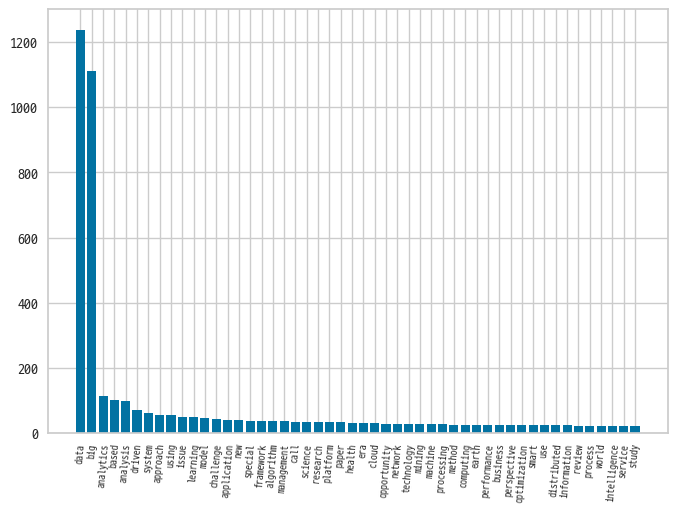

In [38]:
sorted_Keys = sorted(word_count, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count.values(), reverse = True)
plt.bar(range(len(word_count)), sorted_Values, align = 'center')
plt.xticks( range(len(word_count)), list(sorted_Keys), rotation = 85, fontsize=7) #막대그래프의 가로축 눈금에 단어 이름을 표시
plt.show()

In [ ]:
# 빈도가 너무 많은 data, big 제거
word_count2 = word_count
del word_count2['big']
del word_count2['data']
word_count2

{'analytics': 113,
 'based': 102,
 'analysis': 97,
 'driven': 71,
 'system': 62,
 'approach': 56,
 'using': 56,
 'issue': 48,
 'learning': 48,
 'model': 46,
 'challenge': 44,
 'application': 40,
 'new': 39,
 'special': 37,
 'framework': 36,
 'algorithm': 36,
 'management': 36,
 'call': 34,
 'science': 34,
 'research': 34,
 'platform': 34,
 'paper': 32,
 'health': 31,
 'era': 30,
 'cloud': 30,
 'opportunity': 28,
 'network': 27,
 'technology': 26,
 'mining': 26,
 'machine': 26,
 'processing': 26,
 'method': 25,
 'computing': 25,
 'earth': 25,
 'performance': 25,
 'business': 24,
 'perspective': 24,
 'optimization': 24,
 'smart': 24,
 'use': 23,
 'distributed': 23,
 'information': 23,
 'review': 22,
 'process': 22,
 'world': 22,
 'intelligence': 21,
 'service': 21,
 'study': 20}

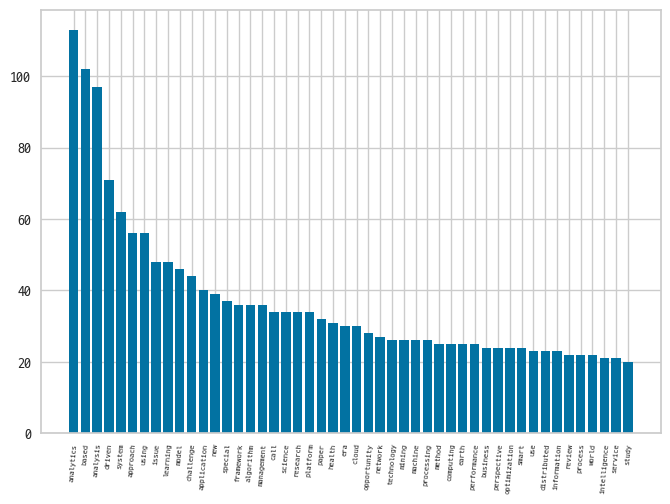

In [40]:
sorted_Keys = sorted(word_count2, key = word_count.get, reverse = True)
sorted_Values = sorted(word_count2.values(), reverse = True)
plt.bar(range(len(word_count2)), sorted_Values, align = 'center')
plt.xticks( range(len(word_count2)), list(sorted_Keys), rotation = 85, fontsize=6)
plt.show()

In [ ]:
# 출판일에 제목 수
summary_year = all_files_data_concat.groupby('출판일', as_index = False)['제목'].count()
summary_year

,출판일,제목
0,2003,1
1,2004,1
2,2011,5
3,2012,19
4,2013,50
5,2014,124
6,2015,92
7,2016,112
8,2017,129
9,2018,118


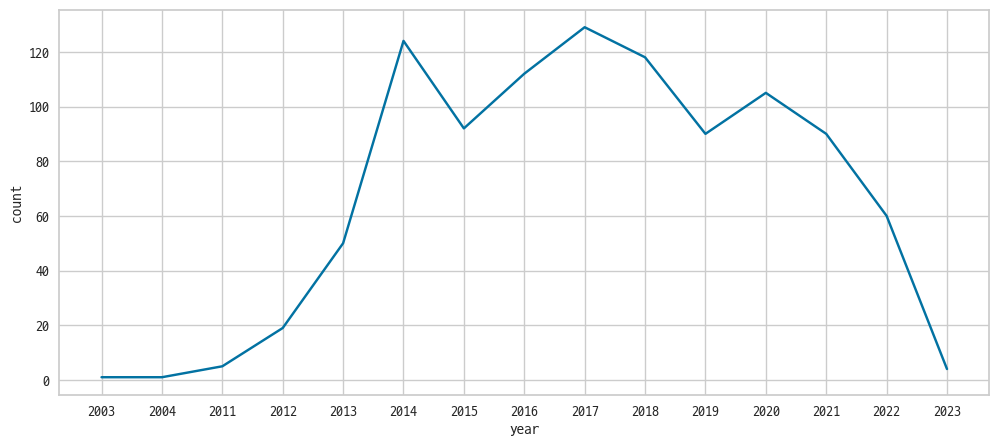

In [42]:
plt.figure(figsize = (12, 5))
plt.xlabel("year")
plt.ylabel("count")
plt.grid(True)
plt.plot(range(len(summary_year)), summary_year['제목'])
plt.xticks( range(len(summary_year)), [text for text in summary_year['출판일']])
plt.show()